# Baseline Model

## Table of Contents
1. Feature Selection
2. Model Choice
    * Simple Linear Models
    * Flexible Models
3. Evaluation of the Baseline Model
4. Implementation & Analysis
    * Average Treatment Effect (ATE)
    * Conditional Average Treatment Effect (CATE)


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import sklearn.linear_model as lm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from patsy import dmatrix

import statsmodels.api as sm
import statsmodels.formula.api as smf

!pip install causaldata
import causaldata

from scipy.stats import norm

import warnings
warnings.simplefilter('ignore')

## Feature Selection

I will start analyzing the impact of the NSW job training program between 12/1975 and 01/1978
on male participants' (hereinafter referred to as ‘participants’) earnings in 1978 by fitting several regression models.
Using a regression model is the standard method used by most econometricians when wanting to identify the (causal) effect, which is why I will
start my analysis with one of those models aswell. Regression models are known to be quite simple, but still deliver good outcomes in most
applications, therefore these make good baseline models. I will try a linear structural model, according to the set of features identified under
the DAG, and a more flexible one to allow for non-linearities.

Finally I will compute the mean square error (MSE) and adjusted $R^2$ for all models and choose a best model according to the best performance in both metrics.

In [ ]:
# Load the dataset
df_raw = causaldata.nsw_mixtape.load_pandas().data

# Remove specified columns
df=df_raw.copy()
df = df.drop(columns=['marr', 'hisp', 'nodegree', 're74'], errors='ignore')

# Handle zeros in re78 before taking log (do +1)
ly78 = np.log(df['re78'] + 1)
ly75 = np.log(df['re75'] + 1)

df['lre78'] = ly78
df['lre75'] = ly75

# Model with all features
X = df[['treat', 'age', 'educ', 'black', 'lre75']]

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, df['lre78'], test_size=0.2, random_state=42)

As can be seen in the following plot, the outcome, real earnings in 1978 are heavily skewed to the right, with most survey respondents earning either 0 or less than 10000\$, and only some respondents earning up to 30000\$ or even 40000\$. This is a common characteristic of earnings data, therefore I will use the log of all earnings features to buffer these potential outliers and get a distribution that is closer to the normal distribution. This is important, because standard causal inference methods are based on the (approximate) normality assumption.

Text(0, 0.5, 'Frequency')

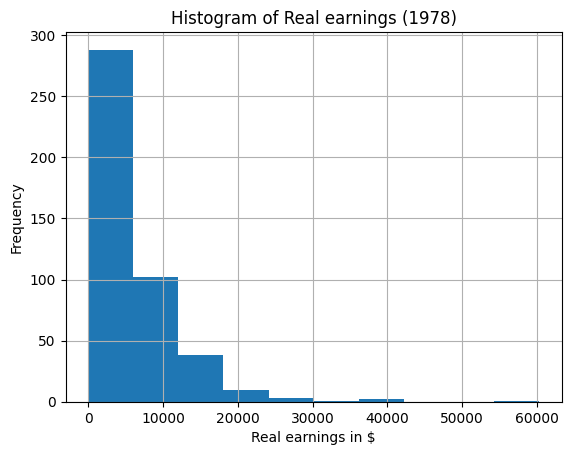

In [ ]:
# Histogram of re78
plot = df['re78'].hist()
plot.set_title('Histogram of Real earnings (1978)')
plot.set_xlabel('Real earnings in $')
plot.set_ylabel('Frequency')

Now, the distribution of wages looks way better, but there are still many people who indicated having zero earnings in 1978:

Text(0, 0.5, 'Frequency')

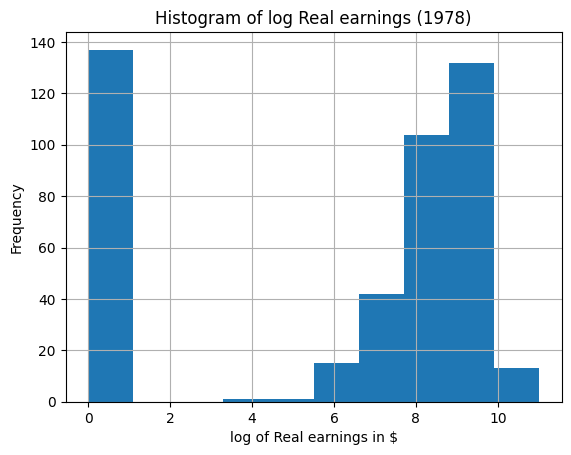

In [ ]:
# Histogram of lre78
plot=df['lre78'].hist()
plot.set_title('Histogram of log Real earnings (1978)')
plot.set_xlabel('log of Real earnings in $')
plot.set_ylabel('Frequency')

As Deheija & Wahba (1999) state that all participants in their subsample took part in the training and the follow-up interview in 1978 (p. 1054), the 0-values are therefore not caused by dropouts or non-compliers.

As there are only compliers in the sample, my estimates using treatment assignment in the following can be causally interpreted as the Local Average Treatment Effect (LATE) for the effect of treatment participation, which is the intention-to-treat (ITT) effect for the compliers.

The effect of the treatment assignment to the program delivers the ITT by construction. This effect, however, cannot always be interpreted causally e.g. due to non-compliers, as noted before. Because my goal is to estimate the impact of treatment participation, these might bias the actual effect, but this is not the case here.

Additionally, because this is a job training program for people struggling with employment, these 0-values should be considered realistic outcomes.

## Model Choice

In the following, I will fit several models to find the best "baseline" model. I will start by fitting a simple linear model and estimate the effects under OLS, either Ridge or LASSO, post-LASSO OLS, the Elastic Net and LAVA using the following linear structural model:

$$
\log(re_{78})=\beta_0+\beta_1 treat+\beta_2 black+\beta_3 educ
+ \beta_4 age+\beta_5 \log(re_{75}) + \epsilon
$$

### Simple Linear Models

In [ ]:
# OLS
# Initialize and train the baseline OLS model
model_base= 'lre78 ~  treat + C(black) + educ + age + lre75'

train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)
y_test = test_df['lre78']

results_OLS_base = smf.ols(model_base, data=train_df).fit()

# predict on test sample
y_pred_OLS_base = results_OLS_base.predict(test_df)

# evaluate fit
MSE_OLS_base = mean_squared_error(y_test, y_pred_OLS_base)


# Adj. R² on test set
ss_res = np.sum((y_test - y_pred_OLS_base) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
n = len(y_test)
k = results_OLS_base.df_model  # number of predictors excluding intercept
R2_test = 1 - (ss_res / ss_tot)
R2_OLS_base = 1 - (1 - R2_test) * (n - 1) / (n - k - 1)

To check, whether Ridge or LASSO methods are more appropriate, I will examine the share of zero values within the feature matrices to determine if the signal environment is sparse or dense. A high share of zeros indicates a sparse environment and a low share indicates a dense environment.

Both Ridge and LASSO estimators help avoid overfitting of the OLS model as they penalize longer, more complicated models. They differ in the penality term, where Ridge uses a quadratic penalty term that works well in a dense signal environment,

$$
\min_{\widehat{\beta}} \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{\beta}' x_i)^{2} + \lambda \sum_{j=1}^{k} \widehat{\beta}_j^2
$$

 and where LASSO uses an absolute penalty term that works well in a sparse environment,

 $$
\min_{\widehat{\beta}} \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{\beta}' x_i)^{2} + \lambda \sum_{j=1}^{k}| \widehat{\beta}_j|.
$$

In [ ]:
# Calculate the percentage of zero values in the baseline feature matrix (X)
percentage_zeros_X = np.mean(X == 0) * 100
print(f"Percentage of zero values: {percentage_zeros_X:.2f}%")


Percentage of zero values: 28.00%


Here, the share of 28% indicates that the environment is rather dense. Therefore, a Ridge regression is more appropriate than LASSO.


In [ ]:
# Set up formula for calculation or adjusted R-squared

def adjusted_r_squared(y_true, y_pred, num_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    k = num_features

    # Formel für Adjusted R-squared
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adj_r2

In [ ]:
# Ridge Regression
feature_cols = ['treat', 'age', 'educ', 'black', 'lre75']
X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_train = train_df['lre78'].values

ridge_base = Pipeline([('scale', StandardScaler()),
                       ('ridge', lm.RidgeCV())])

results_ridge_base = ridge_base.fit(X_train, y_train)
y_pred_ridge_base  = results_ridge_base.predict(X_test)

MSE_RIDGE_base = mean_squared_error(y_test, y_pred_ridge_base)
R2_RIDGE_base  = adjusted_r_squared(y_test, y_pred_ridge_base, len(feature_cols))

Additionally, it might be interesting to try the LAVA method, which combines both the Ridge and LASSO penalties.

Specifically, LAVA decomposes the true parameter into a dense and a sparse component that are either penalized with a Ridge penalty ('l2') or LASSO penalty ('l1'). It then estimates the two components by minimizing the following term,

$$
(\widehat{\theta}, \widehat{\delta}) = \min_{\beta, \delta} \{\frac{1}{n} \sum^n_{i=1} (Y-X(\theta+\delta))^2 + \lambda_2 \theta^2  + \lambda_1 |\delta| \}
$$

and calculates the true estimated parameter by adding the two:

$$
\widehat{\beta}_{LAVA} = \widehat{\theta} + \widehat{\delta}
$$

As the signal environment, however, is quite dense, I do not expect this model to perform better than previous models.

In [ ]:
# LAVA
# Construct an sklearn API estimator that implements the LAVA method (copyright Kristian Boroz)

class Lava(BaseEstimator):

    def __init__(self, *, alpha1=1, alpha2=1, iterations=5):
        self.alpha1 = alpha1  # l1 penalty
        self.alpha2 = alpha2
        self.iterations = iterations

    def fit(self, X, y):
        ridge = lm.Ridge(self.alpha2).fit(X, y)
        lasso = lm.Lasso(self.alpha1).fit(X, y - ridge.predict(X))

        for _ in range(self.iterations - 1):
            ridge = ridge.fit(X, y - lasso.predict(X))
            lasso = lasso.fit(X, y - ridge.predict(X))

        self.lasso_ = lasso
        self.ridge_ = ridge
        return self

    def predict(self, X):
        return self.lasso_.predict(X) + self.ridge_.predict(X)

In [ ]:
adjusted_r_squared_scorer_base = make_scorer(adjusted_r_squared, greater_is_better=True,
                                             needs_proba=False, num_features=len(feature_cols))

lava = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                    scoring=adjusted_r_squared_scorer_base, n_jobs=-1)

result_lava_base = lava.fit(X_train, y_train)

# predict on test data
y_pred_lava_test = result_lava_base.predict(X_test)

# Evaluate on test set
MSE_lava = mean_squared_error(y_test, y_pred_lava_test)
R2_lava  = adjusted_r_squared(y_test, y_pred_lava_test, len(feature_cols))

### Flexible Models

In addition to the simple linear model, I will also fit a fully flexible model that allows for non-linearities:

$$
\log(re_{78})=\beta_0+\beta_1 treat+\beta_2 black+ \beta_3 black \ x\  educ
$$
$$
+\beta_4 educ + \beta_5 age + \beta_6 age^2 +\beta_7 \log(re_{75}) + υ
$$

The model takes into account that the effect of education on earnings might differ for black vs. non-black participants, and that the returns to age are diminishing and not purely linear.

To not risk losing further degrees of freedom, these are the only non-linear specifications I will be testing.


In [ ]:
# OLS
model_flex = 'lre78 ~ treat + C(black) + C(black):educ + educ + age + I(age**2) + lre75'

results_OLS_flex = smf.ols(model_flex, data=train_df).fit()

# Predict on test set
y_pred_OLS_flex = results_OLS_flex.predict(test_df)
y_test_flex     = test_df['lre78']

# Evaluate on test set
MSE_OLS_flex = mean_squared_error(y_test_flex, y_pred_OLS_flex)

ss_res = np.sum((y_test_flex - y_pred_OLS_flex) ** 2)
ss_tot = np.sum((y_test_flex - y_test_flex.mean()) ** 2)
n = len(y_test_flex)
k = results_OLS_flex.df_model
R2_test_flex = 1 - (ss_res / ss_tot)
R2_OLS_flex  = 1 - (1 - R2_test_flex) * (n - 1) / (n - k - 1)

To decide between Ridge and LASSO regressions, I will again check whether the signal environment is rather dense or sparse.

In [ ]:
# Extract design matrix from the flex model fit
X_full_flex = smf.ols(model_flex, data=df).data.exog

percentage_zeros_X_full = np.mean(X_full_flex == 0) * 100
print(f"Percentage of zero values: {percentage_zeros_X_full:.2f}%")

Percentage of zero values: 19.75%


As 19.75% of the signals are zero, the data environment is, again, rather dense. For this reason, I will only fit the flexible model using the Ridge estimator.

In [ ]:
# Ridge
formula_rhs = 'treat + C(black) + C(black):educ + educ + age + I(age**2) + lre75'

X_train_flex = np.array(dmatrix(formula_rhs, data=train_df))
X_test_flex  = np.array(dmatrix(formula_rhs, data=test_df))
y_train_flex = train_df['lre78'].values
y_test_flex  = test_df['lre78'].values

ridge_flex = Pipeline([('scale', StandardScaler()),
                       ('ridge', lm.RidgeCV())])

results_ridge_flex = ridge_flex.fit(X_train_flex, y_train_flex)
y_pred_ridge_flex  = results_ridge_flex.predict(X_test_flex)

MSE_RIDGE_flex = mean_squared_error(y_test_flex, y_pred_ridge_flex)
R2_RIDGE_flex  = adjusted_r_squared(y_test_flex, y_pred_ridge_flex,
                                    X_train_flex.shape[1] - 1)

As before, I will also try the LAVA estimator, but still do not expect it to perform better than the Ridge model.

In [ ]:
# LAVA
num_features_flex_lava = X_train_flex.shape[1] - 1

adjusted_r_squared_scorer_flex = make_scorer(adjusted_r_squared, greater_is_better=True,
                                             needs_proba=False, num_features=num_features_flex_lava)

lava_flex = GridSearchCV(Lava(), {'alpha1': np.logspace(-4, 4, 20), 'alpha2': np.logspace(-4, 4, 20)},
                         scoring=adjusted_r_squared_scorer_flex, n_jobs=-1)

result_lava_flex = lava_flex.fit(X_train_flex[:, 1:], y_train_flex)
y_pred_lava_flex = result_lava_flex.predict(X_test_flex[:, 1:])

# Evaluate on test set
MSE_lava_flex    = mean_squared_error(y_test_flex, y_pred_lava_flex)
R2_lava_flex     = adjusted_r_squared(y_test_flex, y_pred_lava_flex, num_features_flex_lava)

## Evaluation of the Baseline Model

Now, I will compare the best models from each "category" to find the best baseline model for the following analysis, based on a trade-off of their performance in terms of mean squared error (MSE) and a measure of model fit, the adjusted $R^2$.

The MSE measures the average squared deviation of the fitted values under the model from the actual values,

$$
MSE= \frac{1}{n} \sum^n_{i=1}(Y_i-\widehat{Y_i})^2.
$$

This measure is very technical, but shows how good the model fits the data. The lower the MSE, the better the model fits the data.

Compared to that, the $R^2$ measures the share of variation in the outcome that can be explained by the variation in the features,

$$
R^2= 1-\frac{RSS}{TSS}=\frac{\sum(\hat{y_i}-\bar{y_i})^2}{\sum(y_i-\bar{y_i})^2},
$$

with RSS (residual sum of squares) being the sum of squared residuals and TSS (total sum of squares) the being the total variance of the target variable. It displays the share of the variation in the target variable that can be explained by the variation in the features, and gives a more intuitive interpretation.

The adjusted $R^2$ then takes the size of the model into account and penalizes models with more features. The higher the adj. $R^2$, the more variation in the target variable can be explained by the variation in the features.





In [ ]:
table_base = pd.DataFrame({
    'Linear OLS': [MSE_OLS_base, R2_OLS_base],
    'Linear Ridge': [MSE_RIDGE_base, R2_RIDGE_base],
    'Linear LAVA': [MSE_lava, R2_lava],
    'Flexible OLS': [MSE_OLS_flex, R2_OLS_flex],
    'Flexible Ridge': [MSE_RIDGE_flex, R2_RIDGE_flex],
    'Flexible LAVA': [MSE_lava_flex, R2_lava_flex]
}).T
table_base.columns = ['Mean squared error', 'Adjusted R-squared']
display(table_base)
table_base.to_csv('model_evaluation_regression.csv')

,Mean squared error,Adjusted R-squared
Linear OLS,13.667609,-0.083643
Linear Ridge,13.640724,-0.081512
Linear LAVA,13.667608,-0.083643
Flexible OLS,13.881520,-0.127779
Flexible Ridge,13.564892,-0.102055
Flexible LAVA,13.881471,-0.127775


In terms of MSE, the flexible Ridge model has the lowest value, closely followed by the linear Ridge and linear OLS/linear LAVA models.

In terms of adjusted $R^2$, however, all models overfit the test data, and all flexible models overfit 'worse' than all linear models.

As all models perform quite similarly overall, I will choose the linear OLS model to continue my analysis with, as the linear Ridge model might introduce additional shrinking bias due to regularization.
The linear OLS instead delivers unbiased estimates.

This will become even clearer when inspecting the absolute difference between the estimated linear Ridge and linear OLS coefficients.


In [ ]:
# Inspect shrinkage bias

# Linear OLS
ols_results = smf.ols(model_base, data=df).fit()

ols_coef = ols_results.params['treat'] # store treatment coefficient

# Linear Ridge
ridge_base.fit(df[feature_cols].values, df['lre78'].values)

ridge_model = ridge_base.named_steps['ridge'] # Extract the RidgeCV model from the pipeline
treat_idx = feature_cols.index('treat')
ridge_coef = ridge_model.coef_[treat_idx]

print(f"OLS coefficient: {ols_coef:.4f}")
print(f"Ridge coefficient: {ridge_coef:.4f}")

OLS coefficient: 0.9867
Ridge coefficient: 0.4757


The decision of choosing OLS is justified as the estimate under the Ridge estimation is a lot smaller than the OLS estimate and therefore be influenced by non-negligible shrinkage bias.

## Implementation & Analysis

### Average Treatment Effect (ATE)

As my main goal is to estimate treatment effects of the NSW job training program on participant earnings, I will continue by calculating both the average and conditional average treatment effects (ATE, CATE) using the best model I have identified in the previous section.

I will first calculate a naive ATE based on the the treatment coefficient from the linear OLS regression,

$$
\tau=E \ [Y_i(1)-Y_i(0)],
$$

which is consistent when the estimated treatment effects $ \widehat{\mu}_{(w)}(x)$ are consistent for the true treatment effects $ \mu_{(w)}(x)$.

I am already confident that the naive ATE is unbiased and hence consistent, but I will still additionally calculate the ATE using the augmented inverse propensity weighting (AIPW) estimator. This is a doubly robust estimator of the ATE that uses the propensity weighting on the residuals to debias the direct estimate. It ensures that the estimated treatment effect is consistent even if either the outcome model or the propensity model is incorrectly specified:


$$
\widehat{\tau}_{AIPW}=D+R,
$$

where
$$
D=\frac{1}{n} \sum^n_{i=1} (\widehat{\mu}_{(1)} (X_i) - \widehat{\mu}_{(0)} (X_i))
$$

and
$$
R=\frac{1}{n} \sum^n_{i=1} (\frac{W_i}{\widehat{e}(X_i)} (Y_i - \widehat{\mu}_{(1)}(X_i)) - \frac{1-W_i}{1-\widehat{e}(X_i)} (Y_i - \widehat{\mu}_{(0)}(X_i))).
$$

D works as a direct regression adjustment estimator and R is a regular inverse propensity weighted (IPW) estimator applied to the residuals $Y_i-\widehat{\mu}_{(W_i)}(X_i)$.

Additionally, I will use cross-fitting and overlapping to get good behaviour of the AIPW and ensure statistical inference.

In [ ]:
# Naive ATE
ate_naive_OLS = results_OLS_base.params['treat']
ate_naive_OLS_pc = (math.exp(ate_naive_OLS) - 1) * 100

In [ ]:
# Data preparation for AIPW

# set up model without 'treat'
model_base_aipw = 'lre78 ~ age + educ + C(black) + lre75'
tmp_aipw = smf.ols(model_base_aipw, data=df)
X_aipw = tmp_aipw.data.exog
y_aipw = tmp_aipw.data.endog
T_aipw = df['treat'].values

# Define the number of splits for cross-fitting
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1)

# Initialize arrays to store out-of-fold predictions
m0_oof = np.zeros(len(df))
m1_oof = np.zeros(len(df))
p_scores_oof = np.zeros(len(df))
y_oof = np.zeros(len(df))
T_oof = np.zeros(len(df))

# Cross-fitting
for fold, (train_index, test_index) in enumerate(kf.split(X_aipw)):
    # Split data for the current fold
    X_train_fold, X_test_fold = X_aipw[train_index], X_aipw[test_index]
    y_train_fold, y_test_fold = y_aipw[train_index], y_aipw[test_index]
    T_train_fold, T_test_fold = T_aipw[train_index], T_aipw[test_index]

    # Store actual y and T values for the test fold
    y_oof[test_index] = y_test_fold
    T_oof[test_index] = T_test_fold

# Estimate propensity score (logistic regression)
    X_train_non_intercept = X_train_fold[:, 1:]
    X_test_non_intercept = X_test_fold[:, 1:]

    scaler = StandardScaler()
    X_train_scaled = np.hstack((X_train_fold[:, :1], scaler.fit_transform(X_train_non_intercept)))
    X_test_scaled = np.hstack((X_test_fold[:, :1], scaler.transform(X_test_non_intercept)))

    propensity_model = LogisticRegression(solver='liblinear', random_state=1, fit_intercept=False)
    propensity_model.fit(X_train_scaled, T_train_fold)

    # Predict propensity scores for the test fold
    p_scores_oof[test_index] = propensity_model.predict_proba(X_test_scaled)[:, 1]

# Estimate outcome model for control group (T=0)
    X_train_control = X_train_fold[T_train_fold == 0]
    y_train_control = y_train_fold[T_train_fold == 0]

    ols_m0 = sm.OLS(y_train_control, X_train_control).fit()

    m0_oof[test_index] = ols_m0.predict(X_test_fold)

# Estimate outcome model for treatment group (T=1)
    X_train_treated = X_train_fold[T_train_fold == 1]
    y_train_treated = y_train_fold[T_train_fold == 1]

    ols_m1 = sm.OLS(y_train_treated, X_train_treated).fit()

    m1_oof[test_index] = ols_m1.predict(X_test_fold)

# Ensure overlap of propensity scores (clip)
epsilon = 1e-7
p_scores_oof = np.clip(p_scores_oof, epsilon, 1 - epsilon)

# Calculate ATE with out-of-fold predictions
aipw_terms = (m1_oof - m0_oof +
              (T_oof * (y_oof - m1_oof) / p_scores_oof) +
              ((1 - T_oof) * (y_oof - m0_oof) / (1 - p_scores_oof)))

ate_aipw_crossfit = np.mean(aipw_terms)

# Calculate percentage from log values
ate_aipw_pc = (math.exp(ate_aipw_crossfit)-1)*100

# Comparison of ATE estimates
print(f"Naive ATE from OLS: {ate_naive_OLS:.4f}")
print(f"ATE from AIPW: {ate_aipw_crossfit:.4f}")

Naive ATE from OLS: 1.0643
ATE from AIPW: 1.0294


The naive ATE (1.06) is quite similar to the ATE under AIPW (1.03), but it is a little higher, which shows that the naive estimate suffers from a small positive bias.

As I it is very unlikely that omitted variable bias is the problem (by the nature of a RCT) and as I am assuming that attrition is no problem, a potential explanation is that the linear structural model is misspecified and does not capture the underlying non-linear structure well, which can introduce a bias. The proposed flexible model, however, had even worse model fit than the linear model, so this one was clearly also not appropriate.

For this reason, it is necessary to use the AIPW estimate which can account for this bias.

In [ ]:
# Calculate percentages

print(f"Naive ATE from OLS: {ate_naive_OLS_pc:.2f}%")
print(f"ATE from AIPW: {ate_aipw_pc:.2f}%")
print(f"Difference: {ate_naive_OLS_pc-ate_aipw_pc:.2f}")

Naive ATE from OLS: 189.88%
ATE from AIPW: 179.93%
Difference: 9.95


The (small) positive bias in the naive OLS estimate can also be seen from the percentage values, as the OLS estimates the average effect of job training participation on post-treatment earnings to be around 10 pp higher than under the AIPW compared to the control group.


Finally, I will verify if the treatment effects estimated under OLS and AIPW are both significant at 5% level and actually have a statistically significant effect on post-treatment earnings.

In [ ]:
# p-value for naive OLS
ols_p_value = results_OLS_base.pvalues['treat']

print(f"P-value for OLS ATE: {ols_p_value:.4f}")


# p-value for AIPW ATE
n = len(aipw_terms)
std_err_aipw = np.std(aipw_terms, ddof=1) / np.sqrt(n)

# Two-sided p-value
p_value_aipw = 2 * (1 - norm.cdf(abs(ate_aipw_crossfit / std_err_aipw)))

print(f"P-value for AIPW ATE: {p_value_aipw:.4f}")

P-value for OLS ATE: 0.0146
P-value for AIPW ATE: 0.0087


As both values are absolutely smaller than 0.05, I can conclude that taking part in the job training increases participants' earnings by around 180% on average (AIPW) on a 5% significance level, keeping all else equal.

### Conditional Average Treatment Effect (CATE)

Additionally, I will report the average treatment effects conditional on the characteristics of a certain subpopulation (CATE),

$$
\tau(x)=E\ [Y^{(1)}-Y^{(0)} | \ X=x],
$$

 based on individual AIPW predictions from before. As can be seen, there is substantial heterogeneity in treatment effects across the sample.




In [ ]:
# CATE
X_covariates = df[['age', 'educ', 'black', 'lre75']].values

ols_cate = sm.OLS(aipw_terms, sm.add_constant(X_covariates)).fit() # regress on X to get conditional values

# CATEs = fitted values
cates = ols_cate.fittedvalues
cate_pc = (np.exp(cates) - 1) * 100

cate_min_pc = (np.exp(np.min(cates))-1)*100
cate_max_pc = (np.exp(np.max(cates))-1)*100

print(f"\nMinimum CATE: {cate_min_pc:.4f}")
print(f"Maximum CATE: {cate_max_pc:.4f}")


Minimum CATE: -45.1774
Maximum CATE: 2392.8186


For some individuals, participation in the job training actually decreased earnings by 45.18% compared to the control group, which could imply they were employed before the training and became unemployed after. Conversely, some participants experienced substantial gains in earnings, with the maximum observed increase being at around 2392.82%.

While this maximum treatment effect appears very high, it is important to consider the context of the data. This program targets disadvantaged individuals who often have very low or zero pre-treatment earnings. For someone starting with minimal income, even a modest absolute increase can translate into a very large percentage change.

However, as can be seen in the following plot, these very high treatment effects are caused by a few outliers and the majority of participants only experiences treatment effects lower than 300%.

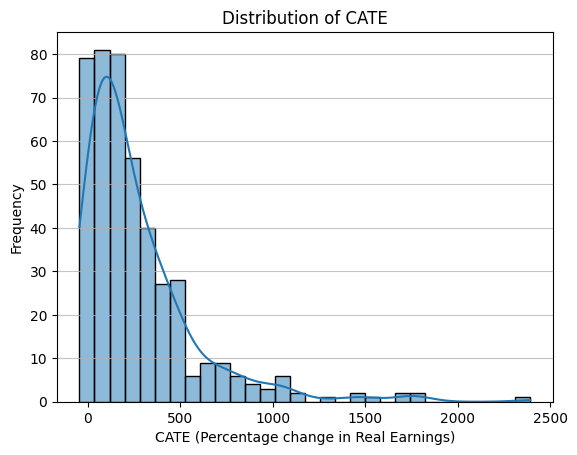

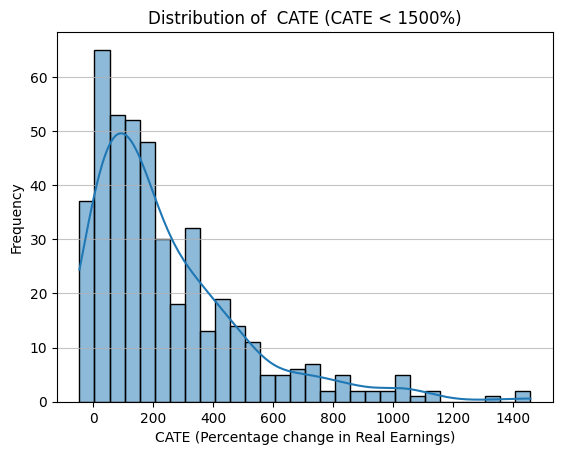

In [ ]:
# in percentages:
sb.histplot(cate_pc, bins=30, kde=True)
plt.title('Distribution of CATE')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Filter CATE values smaller than 1500%
cate_pc_filtered = cate_pc[cate_pc < 1500]

sb.histplot(cate_pc_filtered, bins=30, kde=True)
plt.title('Distribution of  CATE (CATE < 1500%)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()